In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs

In [56]:
headers = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]

cleavland = pd.read_csv("../DSBDALExamDatasets/HeartDisease/Cleavland.csv", names = headers, na_values = "?")
hungary = pd.read_csv("../DSBDALExamDatasets/HeartDisease/hung.csv", names = headers, na_values = "?")
switzerland = pd.read_csv("../DSBDALExamDatasets/HeartDisease/Switzerland.csv", names = headers, na_values = "?")

cleavland["dataset"] = "Cleavland"
hungary["dataset"] = "Hungary"
switzerland["dataset"] = "Switzerland"

df = pd.concat([cleavland, hungary, switzerland], ignore_index = True)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,dataset
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,Cleavland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,Cleavland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,Cleavland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,Cleavland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,Cleavland


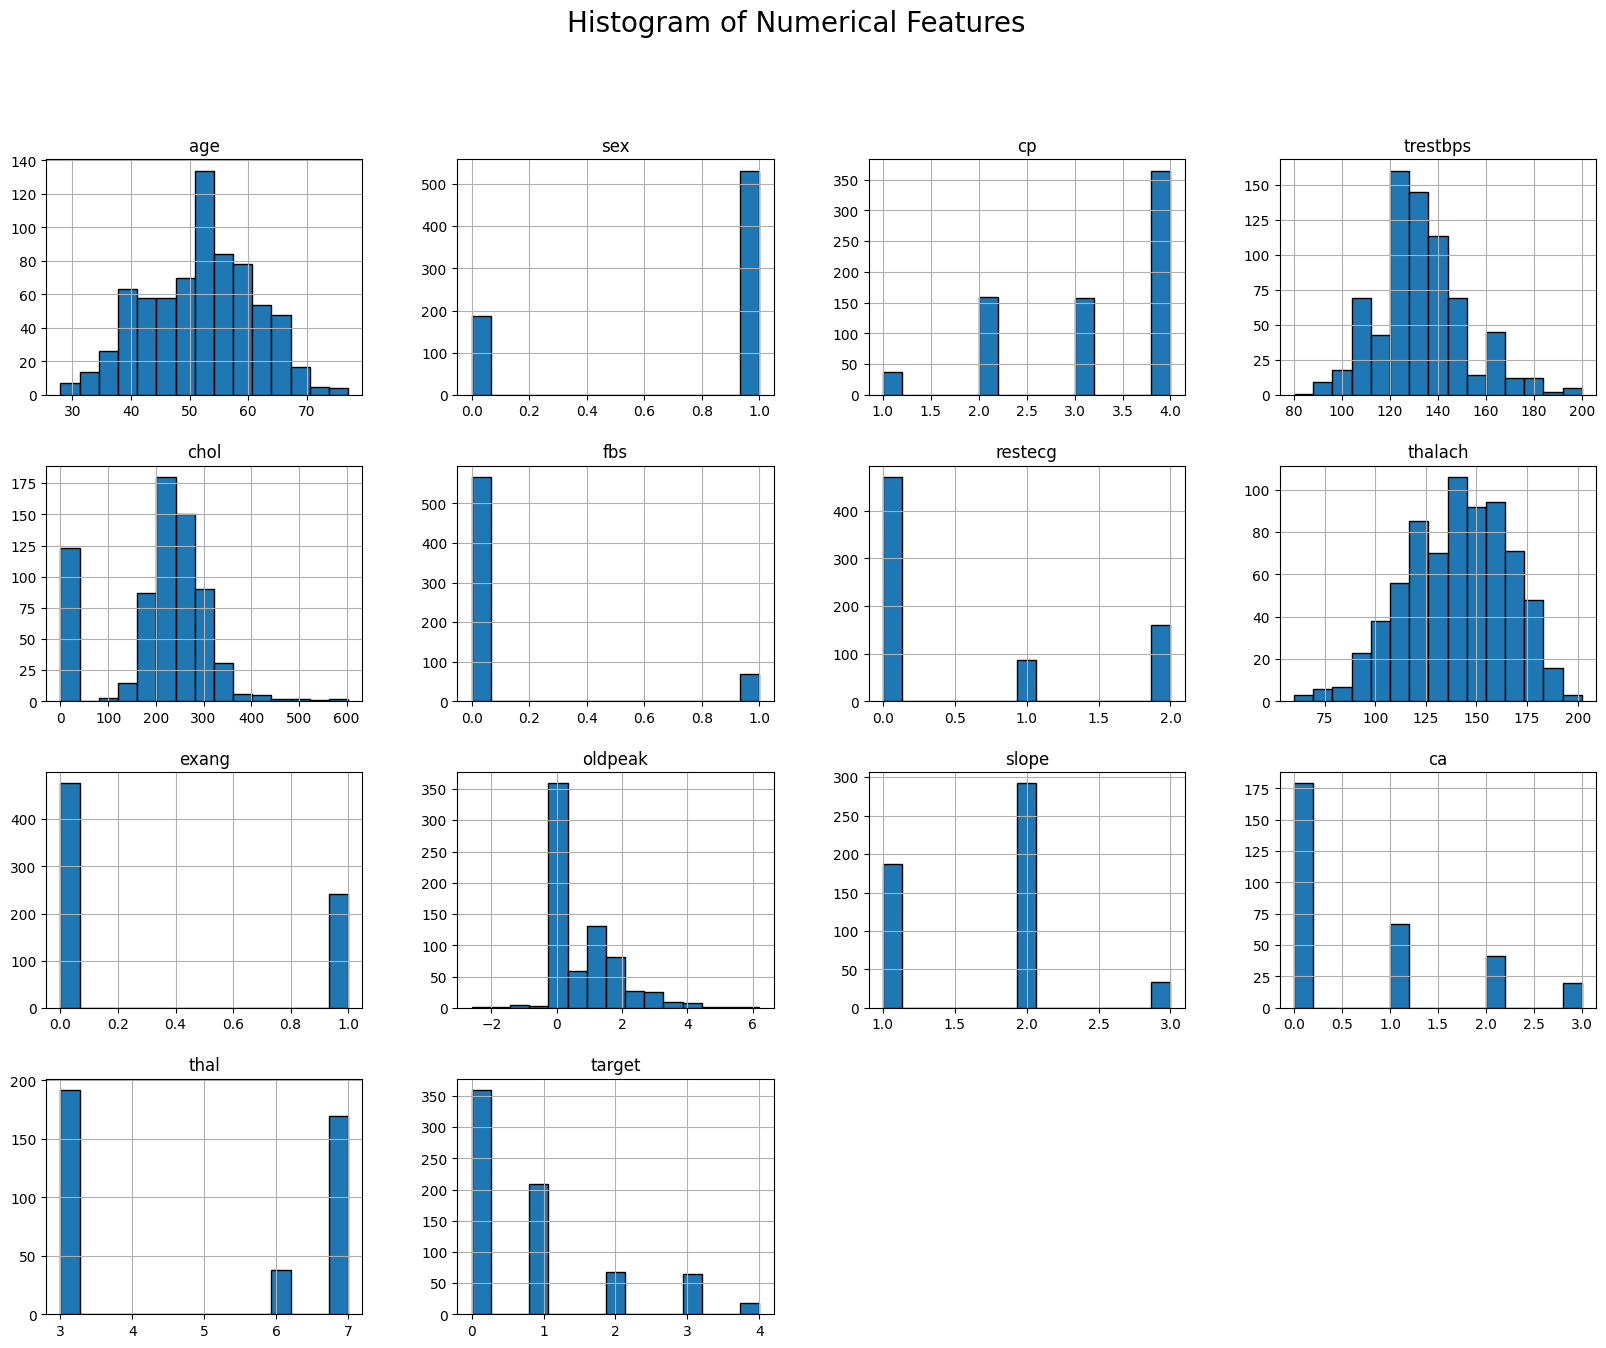

<Figure size 2000x1500 with 0 Axes>

In [57]:
df.hist(bins = 15, figsize = (20, 15), edgecolor = "black")
plt.suptitle("Histogram of Numerical Features", fontsize = 20)
plt.figure(figsize = (20, 15))
plt.show()

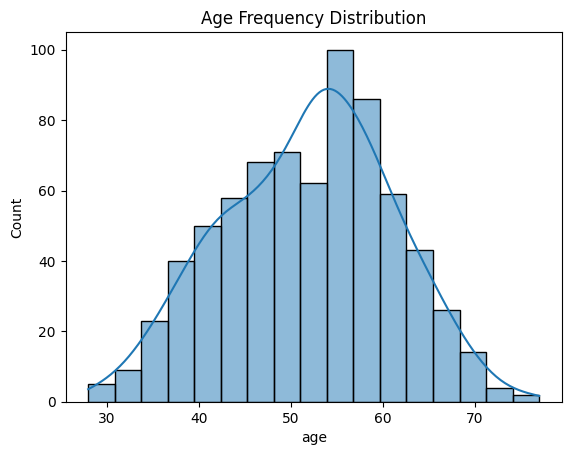

In [58]:
sns.histplot(df, x = "age", kde = True)
plt.title("Age Frequency Distribution")
plt.show()

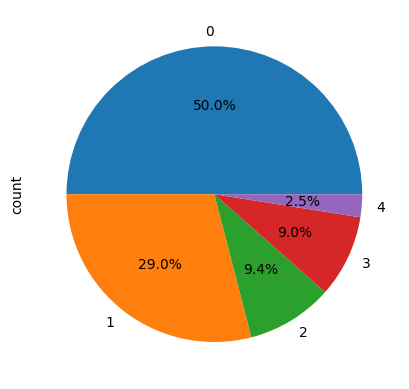

In [59]:
df["target"].value_counts().plot.pie( autopct='%1.1f%%')
plt.show()


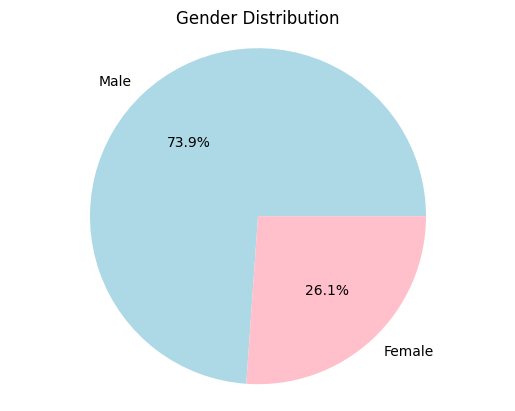

In [60]:
sex_counts = df["sex"].value_counts()
plt.pie(sex_counts, autopct = "%1.1f%%", colors = ["lightblue", "pink"], labels = ["Male", "Female"])
plt.title("Gender Distribution")
plt.axis("equal")
plt.show()

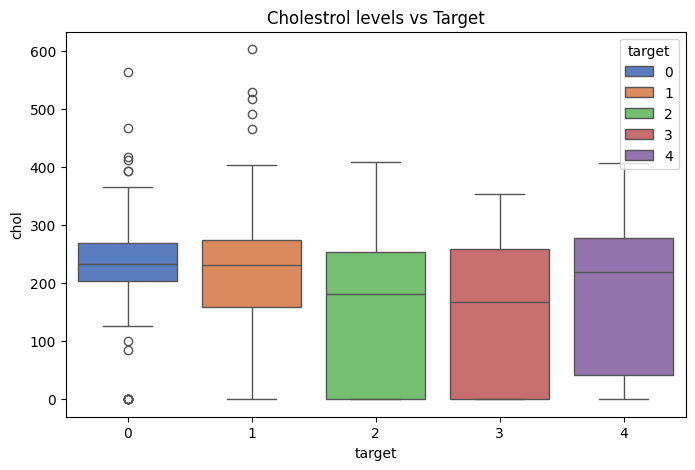

In [61]:
plt.figure(figsize = (8,5))
sns.boxplot(df, x = "target", y = "chol",hue = "target", palette = "muted")
plt.title("Cholestrol levels vs Target")
plt.show()

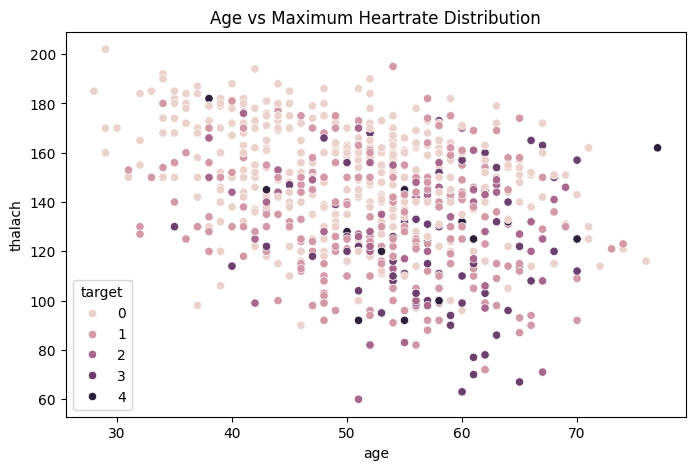

In [62]:
plt.figure(figsize = (8,5))
sns.scatterplot(df, x = "age", y = "thalach", hue = "target")
plt.title("Age vs Maximum Heartrate Distribution")
plt.show()

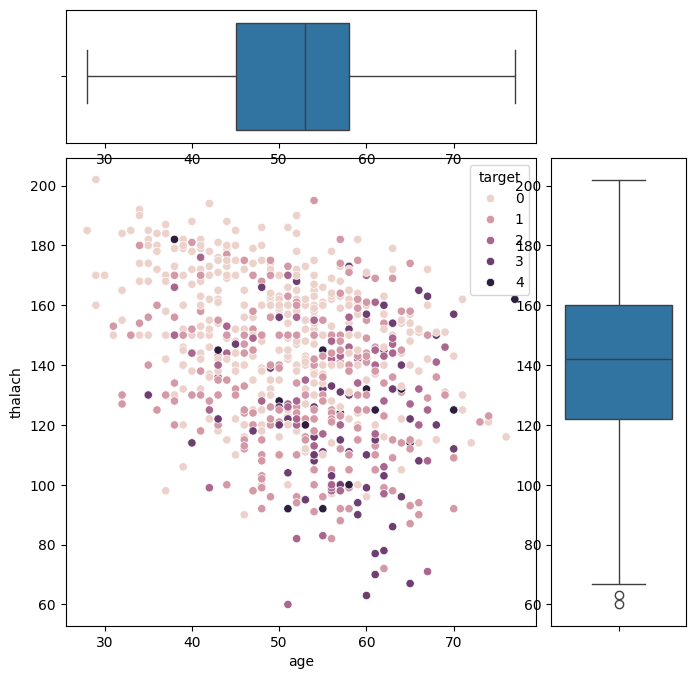

In [77]:
plt.figure(figsize = (8, 8))
grid = gs.GridSpec(2, 2,
                   width_ratios = [7,2],
                   height_ratios = [2, 7],
                   wspace = 0.05,
                   hspace = 0.05)

ax_scatter = plt.subplot(grid[1,0])
ax_top = plt.subplot(grid[0,0], sharex = ax_scatter)
ax_right = plt.subplot(grid[1, 1], sharey = ax_scatter)

sns.scatterplot(df, x = "age", y = "thalach", ax = ax_scatter, hue = "target")
sns.boxplot(df, x = "age", ax = ax_top)
sns.boxplot(df, y = "thalach", ax = ax_right)

ax_top.set(xlabel = '')
ax_right.set(ylabel = '')

plt.show()